In [1]:
import os
os.chdir('../../../../..')

In [2]:
from src.datasets import MaterialsProject

In [3]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from src.helper_functions import create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster
from src.non_euclidean import Riemann, Grassmann, Wasserstein, PersistentHomology

In [4]:
mp = MaterialsProject(limit=1000, sampling_strategy="stratified", stratify_on=["band_gap", "energy_above_hull"], descriptors=["mace"])
df = mp.load()

2026-04-30 17:50:56.511 | INFO     | src.datasets:load:1998 - Loading full cached Parquet data from data/Materials Project/materials.parquet...
2026-04-30 17:50:57.840 | INFO     | src.datasets:_add_descriptors:2371 - Ignoring output_tag=sample_n1200_seed40_stratified since descriptors are attached directly to dataframe.
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
2026-04-30 17:50:58.042 | INFO     | src.datasets:_add_descriptors:2421 - Loading MACE-MP model...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:199: UserWar

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using Materials Project MACE for MACECalculator with /Users/karlfindhansen/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


2026-04-30 17:50:58.174 | INFO     | src.datasets:_add_descriptors:2461 - Computing MACE chunk 0 (0 to 1000)...
2026-04-30 17:58:30.006 | INFO     | src.datasets:_add_descriptors:2461 - Computing MACE chunk 1 (1000 to 1200)...
2026-04-30 17:59:52.989 | INFO     | src.datasets:_add_descriptors:2511 - Added Materials Project descriptor embedding column(s): ['mace_embedding', 'mace_matrix']
2026-04-30 17:59:52.989 | SUCCESS  | src.datasets:_add_descriptors:2516 - All requested descriptors successfully added to dataframe.
2026-04-30 17:59:53.063 | SUCCESS  | src.datasets:load:2044 - Successfully reached requested limit of 1000 valid rows (Attempt 1).


# Riemann

In [5]:
riemann = Riemann()
dist_matrix_riemann = riemann.distance_matrix(df=df, descriptor='mace')

2026-04-30 17:59:53.072 | INFO     | src.non_euclidean:_load_cached_distance_matrix:404 - Loading cached riemann distance matrix from /Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/data/Materials Project/non_euclidean_cache/riemann_materials-project_n1000_mace_affine-invariant_nopca.npy


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_95572/67892373.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link_riemann = linkage(dist_matrix_riemann, method='complete')


(array([1, 2, 3, 4, 5], dtype=int32), array([ 39,   1, 115, 514, 331]))


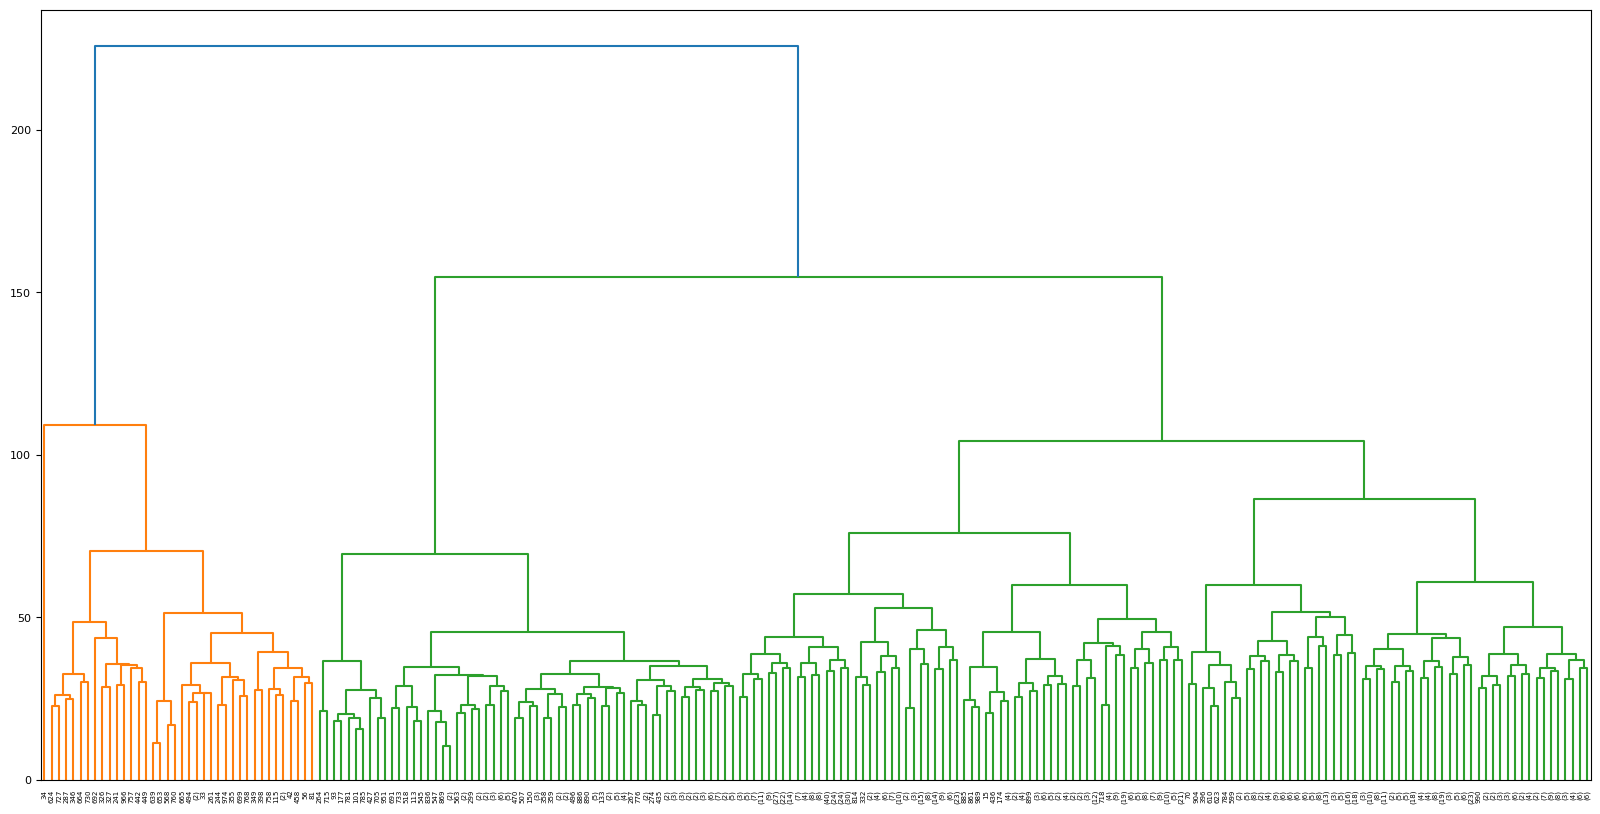

In [6]:
link_riemann = linkage(dist_matrix_riemann, method='complete')
plt.figure(figsize=(20,10))
dendrogram(link_riemann, p=8, truncate_mode='level')
labels_riemann = fcluster(link_riemann, t=100, criterion='distance')
df = df.with_columns(labels_riemann=labels_riemann)
print(np.unique(labels_riemann, return_counts=True))

In [7]:
d = average_numeric_by_cluster(df, "labels_riemann")

shape: (5, 35)
┌────────────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬───────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┬───────────────────────────┬──────────────────────┬──────────────────────────┐
│ labels_riemann ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a       ┆ b       ┆ c       ┆ alpha   ┆ beta    ┆ gamma   ┆ volume    ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ is_injected ┆ pct_metal ┆ unique_crystal_systems ┆ top_crystal_system ┆ top_crystal_system_pct ┆ u

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


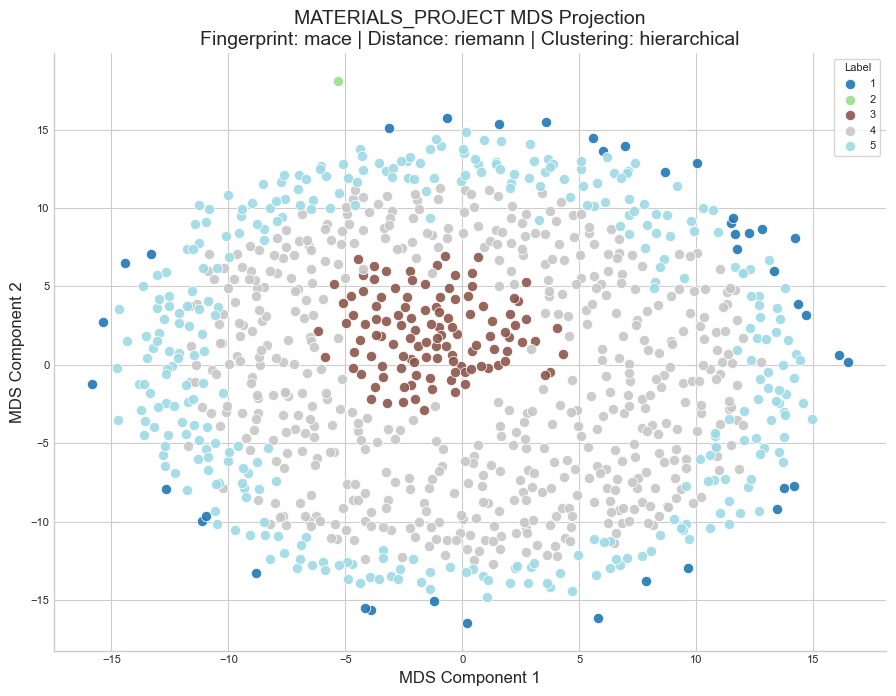

2026-04-30 18:00:02.152 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved MDS projection plot to figures/materials_project/clustering/riemann/mace/mds_hierarchical_projection.png


In [8]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix_riemann,
    fingerprint="mace",
    distance_metric="riemann",
    projection_method="MDS",
    dataset_name="materials_project",
    labels=labels_riemann,
    clustering_method="hierarchical"
)

In [9]:
create_chemiscope_viewer(df, dist_matrix_riemann, labels_riemann, 'MDS')

2026-04-30 18:00:02.157 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running MDS dimensionality reduction...
2026-04-30 18:00:02.158 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-04-30 18:00:10.792 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assemblin

<ChemiscopeWidget(meta={'name': 'Materials Project - MDS Clustering'}, settings={'map': {'x': {'property': 'MD…

# Grassmann

In [10]:
grassmann = Grassmann()
dist_matrix_grassmann = grassmann.distance_matrix(df=df, descriptor='mace')

2026-04-30 18:00:10.917 | INFO     | src.non_euclidean:_load_cached_distance_matrix:404 - Loading cached grassmann distance matrix from /Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/data/Materials Project/non_euclidean_cache/grassmann_materials-project_n1000_mace_k3_svd_norm.npy


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_95572/210872162.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link_grassmann = linkage(dist_matrix_grassmann, method='complete')


(array([1], dtype=int32), array([1000]))


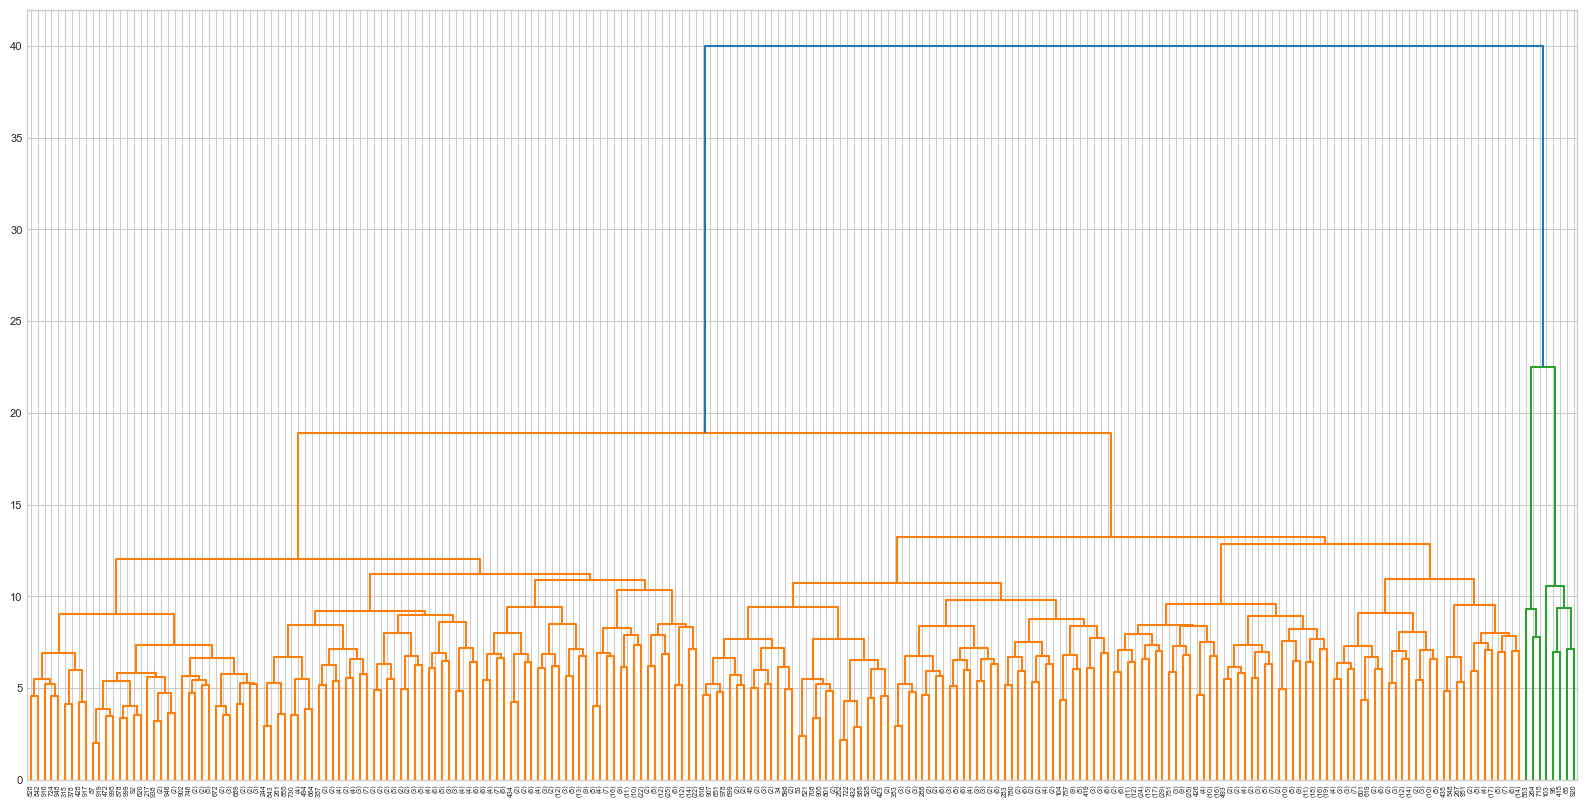

In [11]:
link_grassmann = linkage(dist_matrix_grassmann, method='complete')
plt.figure(figsize=(20,10))
dendrogram(link_grassmann, p=8, truncate_mode='level')
labels_grassmann  = fcluster(link_grassmann, t=48, criterion='distance')
df = df.with_columns(labels_grassmann=labels_grassmann)
print(np.unique(labels_grassmann, return_counts=True))

In [12]:
d = average_numeric_by_cluster(df, "labels_grassmann")

shape: (1, 36)
┌──────────────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬────────────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┬───────────────────────────┬──────────────────────┬──────────────────────────┐
│ labels_grassmann ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c      ┆ alpha   ┆ beta    ┆ gamma   ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ is_injected ┆ labels_riemann ┆ pct_metal ┆ unique_crystal_systems ┆ top_crystal_syste

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


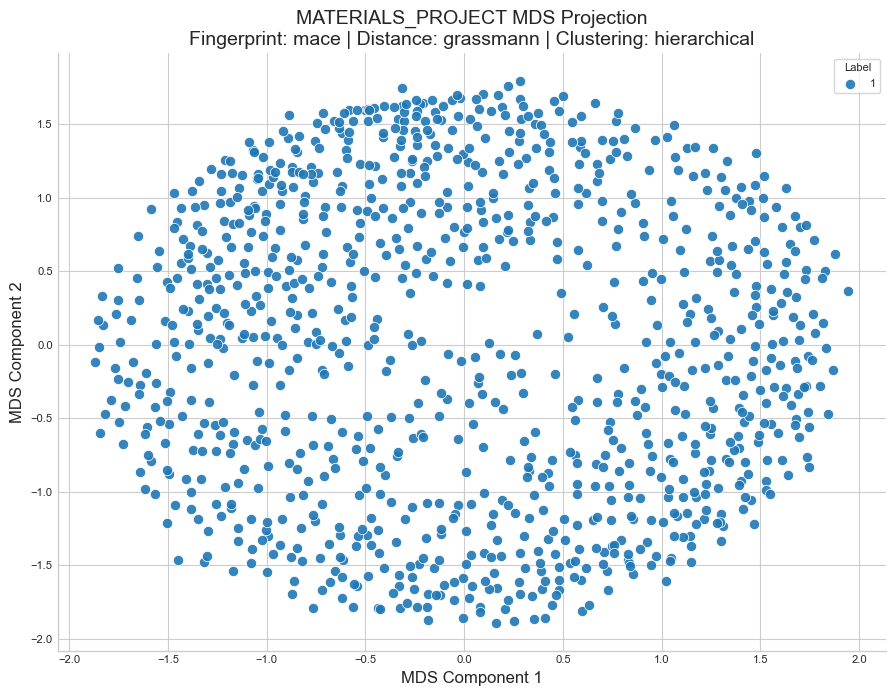

2026-04-30 18:00:20.088 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved MDS projection plot to figures/materials_project/clustering/grassmann/mace/mds_hierarchical_projection.png


In [13]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix_grassmann,
    fingerprint="mace",
    distance_metric="grassmann",
    projection_method="MDS",
    dataset_name="materials_project",
    labels=labels_grassmann,
    clustering_method="hierarchical"
)

In [14]:
create_chemiscope_viewer(df, dist_matrix_grassmann, labels_grassmann, 'MDS')

2026-04-30 18:00:20.100 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running MDS dimensionality reduction...
2026-04-30 18:00:20.101 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-04-30 18:00:29.060 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assemblin

<ChemiscopeWidget(meta={'name': 'Materials Project - MDS Clustering'}, settings={'map': {'x': {'property': 'MD…

# Wasserstein

In [15]:
wasserstein = Wasserstein()
dist_matrix_wasserstein = wasserstein.distance_matrix(df=df, descriptor='mace')

2026-04-30 18:00:29.181 | INFO     | src.non_euclidean:_load_cached_distance_matrix:404 - Loading cached wasserstein distance matrix from /Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/data/Materials Project/non_euclidean_cache/wasserstein_materials-project_n1000_mace_sqeuclidean.npy


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_95572/1754424850.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link_wasserstein = linkage(dist_matrix_wasserstein, method='complete')


(array([1], dtype=int32), array([1000]))


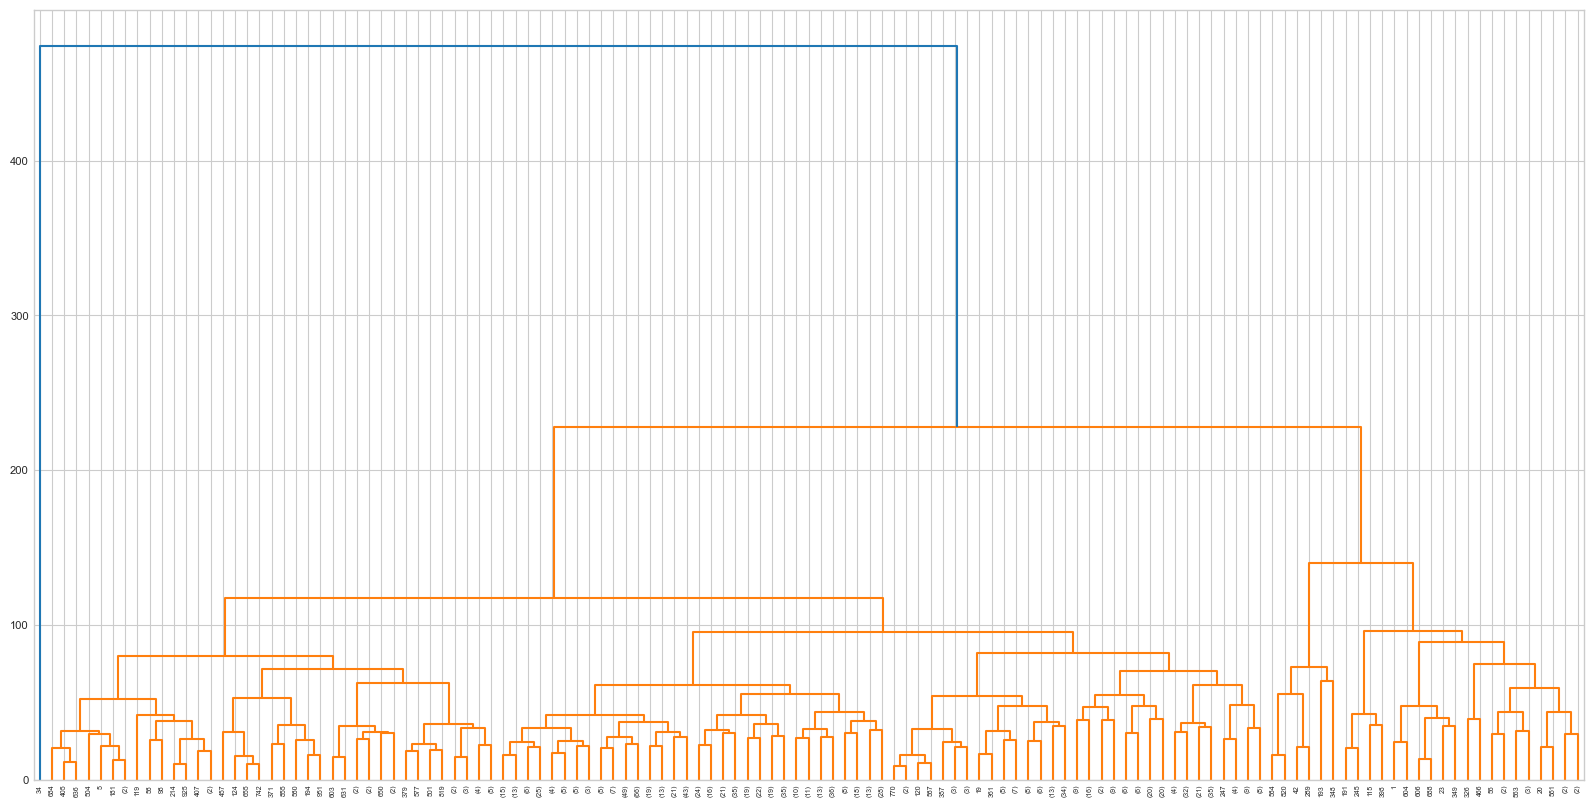

In [16]:
link_wasserstein = linkage(dist_matrix_wasserstein, method='complete')
plt.figure(figsize=(20,10))
dendrogram(link_wasserstein, p=8, truncate_mode='level')
labels_wasserstein  = fcluster(link_wasserstein, t=0.4e7, criterion='distance')
df = df.with_columns(labels_wasserstein=labels_wasserstein)
print(np.unique(labels_wasserstein, return_counts=True))

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


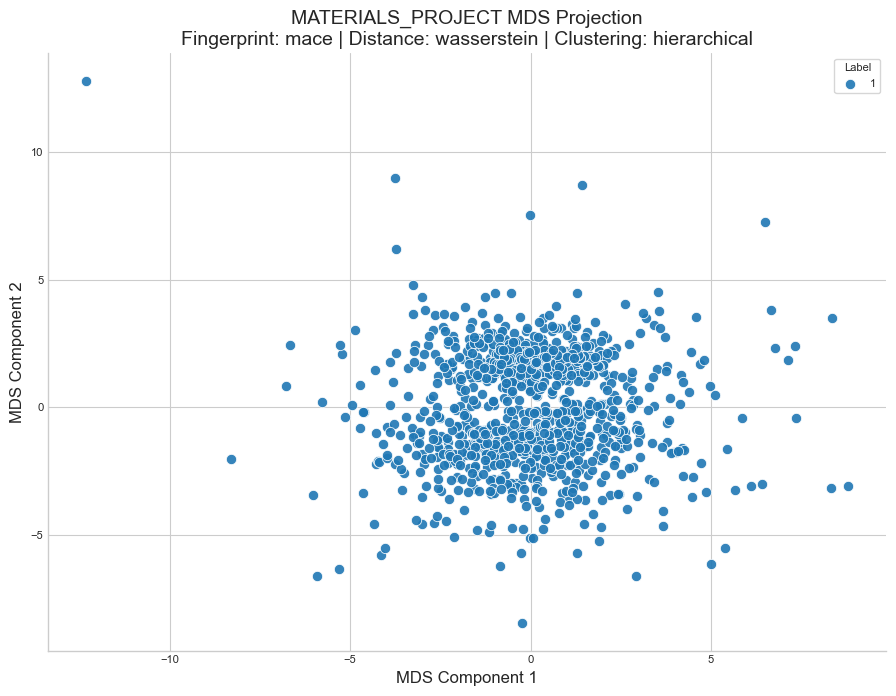

2026-04-30 18:00:37.941 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved MDS projection plot to figures/materials_project/clustering/wasserstein/mace/mds_hierarchical_projection.png


In [17]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix_wasserstein,
    fingerprint="mace",
    distance_metric="wasserstein",
    projection_method="MDS",
    dataset_name="materials_project",
    labels=labels_wasserstein,
    clustering_method="hierarchical"
)

In [18]:
create_chemiscope_viewer(df, dist_matrix_wasserstein, labels_wasserstein, 'MDS')

2026-04-30 18:00:37.952 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running MDS dimensionality reduction...
2026-04-30 18:00:37.953 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-04-30 18:00:46.479 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assemblin

<ChemiscopeWidget(meta={'name': 'Materials Project - MDS Clustering'}, settings={'map': {'x': {'property': 'MD…

In [19]:
d = average_numeric_by_cluster(df, "labels_wasserstein")

shape: (1, 37)
┌────────────────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬────────────────┬──────────────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┬───────────────────────────┬──────────────────────┬──────────────────────────┐
│ labels_wasserstein ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c      ┆ alpha   ┆ beta    ┆ gamma   ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ is_injected ┆ labels_riemann ┆ labels_grassmann ┆ pct_metal ┆ 